# 05 - Model Training & Evaluation

Train a baseline classifier to predict whether a property is
near the beach, then evaluate on the held-out test split.

In [14]:
import os
import sys
from pathlib import Path

path = os.getcwd()
path = os.path.abspath(os.path.join(path, "..", "data"))
DATA_DIR = Path(path)
PROJECT_ROOT = DATA_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = DATA_DIR.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_FILE = PROCESSED_DIR / "train.parquet"
TEST_FILE = PROCESSED_DIR / "test.parquet"
TARGET_COLUMN = "label"
RANDOM_STATE = 42


In [15]:
import joblib
import pandas as pd
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, roc_auc_score

from src.image_features import DEFAULT_IMAGE_CONFIG
from src.model_bundle import build_training_pipeline, get_selected_feature_names, predict_with_bundle

train = pd.read_parquet(TRAIN_FILE)
test = pd.read_parquet(TEST_FILE)
target = TARGET_COLUMN


## Prepare feature matrices

In [16]:
excluded_cols = {target, "filepath", "class_name"}
feature_cols = [c for c in train.columns if c not in excluded_cols]
feature_cols = train[feature_cols].select_dtypes(include="number").columns.tolist()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]
print(f"Using {len(feature_cols)} numeric feature columns")


Using 113 features


## Train baseline model

In [17]:
model = build_training_pipeline(
    feature_cols,
    select_k=60,
    n_estimators=300,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## Evaluate

In [18]:
preds = model.predict(X_test)
test_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))
print(f"ROC AUC          : {roc_auc_score(y_test, test_probs):.4f}")
print(f"Average precision: {average_precision_score(y_test, test_probs):.4f}")


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4982
           1       0.95      0.77      0.85       543

    accuracy                           0.97      5525
   macro avg       0.96      0.88      0.92      5525
weighted avg       0.97      0.97      0.97      5525

Confusion matrix:
[[4959   23]
 [ 127  416]]


## Feature importance

In [19]:
selected_feature_names = get_selected_feature_names(model)
importances = (
    pd.Series(model.named_steps["clf"].feature_importances_, index=selected_feature_names)
    .sort_values(ascending=False)
)
importances.head(20)


hist_b_8     0.053693
hist_b_7     0.045135
hist_b_9     0.045105
hue_cyan     0.041206
hist_b_0     0.036306
               ...   
hist_r_19    0.002375
hist_r_22    0.002309
hist_g_13    0.002214
hist_r_21    0.002165
hist_r_20    0.002116
Length: 113, dtype: float64

## Persist model

In [20]:
model_path = MODELS_DIR / "beach_predictor.joblib"
model_bundle = {
    "model": model,
    "feature_columns": feature_cols,
    "image_config": DEFAULT_IMAGE_CONFIG.to_dict(),
    "selected_feature_names": selected_feature_names,
}
joblib.dump(model_bundle, model_path)
print(f"Saved model bundle -> {model_path}")


Saved model -> /Users/marcel/Documents/github/property-near-the-beach-predictor/models/beach_predictor.joblib


## Test saved model

In [21]:
loaded_bundle = joblib.load(model_path)
loaded_preds, loaded_probs = predict_with_bundle(loaded_bundle, X_test)
print("Reloaded model test-set report:")
print(classification_report(y_test, loaded_preds, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, loaded_preds))


Reloaded model test-set report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4982
           1       0.95      0.77      0.85       543

    accuracy                           0.97      5525
   macro avg       0.96      0.88      0.92      5525
weighted avg       0.97      0.97      0.97      5525

Confusion matrix:
[[4959   23]
 [ 127  416]]


In [22]:
sample_size = 10
sample_X = X_test.head(sample_size)
sample_y = y_test.head(sample_size).reset_index(drop=True)
sample_preds, sample_probs = predict_with_bundle(loaded_bundle, sample_X)
preview = pd.DataFrame({
    "actual": sample_y,
    "predicted": sample_preds,
    "p_beach": sample_probs.round(3),
})
preview


,actual,predicted,p_beach
0,0,0,0.000
1,0,0,0.070
2,0,0,0.020
3,0,0,0.015
4,0,0,0.030
5,0,0,0.005
6,0,0,0.005
7,0,0,0.185
8,0,0,0.000
9,0,0,0.015


## Validation images: display + predict

Load image files from `data/validation`, show each image, and run the saved model prediction.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.image_features import ImageFeatureConfig, extract_feature_frame
from src.model_bundle import unpack_model_bundle

VALIDATION_DIR = DATA_DIR / "validation"
VALIDATION_EXTS = {".jpg", ".jpeg", ".png"}
validation_image_paths = sorted(
    [p for p in VALIDATION_DIR.iterdir() if p.suffix.lower() in VALIDATION_EXTS]
)

print(f"Found {len(validation_image_paths)} validation image(s) in {VALIDATION_DIR}")
validation_image_paths


Found 1 validation image(s) in /Users/marcel/Documents/github/property-near-the-beach-predictor/data/validation


[PosixPath('/Users/marcel/Documents/github/property-near-the-beach-predictor/data/validation/1080p_HBK_autumn-morning_GI-1024x686.jpg')]

/var/folders/qt/93q7l4x510jbfkv63lk0y7f40000gp/T/ipykernel_77703/3268909516.py:26: RuntimeWarning: invalid value encountered in divide
  s = np.where(maxc > 0, delta / maxc, 0.0)


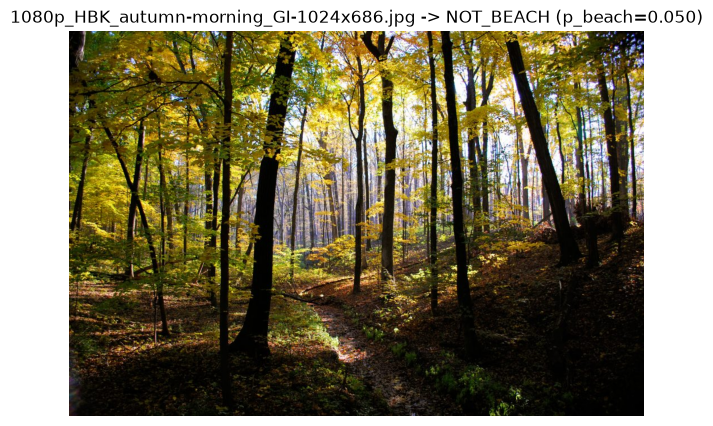

,image,prediction,label,p_beach
0,1080p_HBK_autumn-morning_GI-1024x686.jpg,0,NOT_BEACH,0.05


In [24]:
if "loaded_bundle" not in globals():
    loaded_bundle = joblib.load(model_path)

bundle_info = unpack_model_bundle(loaded_bundle)
feature_config = ImageFeatureConfig(**bundle_info["image_config"])
results = []

for image_path in validation_image_paths:
    img = Image.open(image_path).convert("RGB")
    X_img = extract_feature_frame(
        [img],
        config=feature_config,
        feature_columns=bundle_info["feature_columns"],
    )
    pred, prob = predict_with_bundle(loaded_bundle, X_img)
    pred = int(pred[0])
    p_beach = float(prob[0])

    label = "BEACH" if pred == 1 else "NOT_BEACH"
    title = f"{image_path.name} -> {label}"
    if not np.isnan(p_beach):
        title += f" (p_beach={p_beach:.3f})"

    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

    results.append({
        "image": image_path.name,
        "prediction": pred,
        "label": label,
        "p_beach": p_beach,
    })

pd.DataFrame(results).sort_values("p_beach", ascending=False, na_position="last")
